# Clasificación con Naive Bayes: TMDB Dataset
**Proyecto:** Sistema de Recomendación de Películas basado en TMDB
**Sección:** Clasificación — Naive Bayes
**Dataset:** `pauguzman/tmdb_mineria_datos_processed` (HuggingFace)

Este notebook implementa dos tareas de clasificación supervisada usando **Gaussian Naive Bayes**:

- **C1 — highly_rated** (binaria): predecir si una película será bien valorada (`vote_average ≥ 7.0`)
- **C2 — success_category** (multiclase): predecir la categoría de éxito combinando calidad y popularidad

**Metodología:** Validación cruzada estratificada 5-fold con SMOTE para tratar el desbalance de clases.

**Nota sobre PCA:** Las componentes PC1–PC5 se excluyen deliberadamente. PC1 carga 0.58 sobre `vote_average` (que construye `highly_rated`) y PC3 carga 0.61 sobre `popularity` (que entra en `success_category`). Usarlas introduciría *data leakage* y produciría métricas artificialmente perfectas. Se usan únicamente **24 features de contenido puro** — géneros, duración, año e idioma — igual que en el notebook de Redes Neuronales, garantizando comparabilidad directa entre modelos.

In [1]:
# Instalar librerías necesarias (ejecutar solo si no están disponibles)
!pip install datasets imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset


from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE


from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay
)



import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


Cargar el dataset

In [3]:
ds = load_dataset('pauguzman/tmdb_mineria_datos_processed')
df = ds['train'].to_pandas()

print(f'Dataset: {df.shape[0]:,} películas | {df.shape[1]} variables')
print(f'\nColumnas disponibles:')
for col in df.columns:
    print(f'  {col:30s} {str(df[col].dtype)}')

processed_movies.csv:   0%|          | 0.00/69.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/116929 [00:00<?, ? examples/s]

Dataset: 116,929 películas | 23 variables

Columnas disponibles:
  id                             int64
  title                          object
  vote_average                   float64
  vote_count                     int64
  release_date                   object
  runtime                        int64
  adult                          bool
  original_language              object
  overview                       object
  popularity                     float64
  genres                         object
  production_companies           object
  production_countries           object
  spoken_languages               object
  keywords                       object
  release_year                   float64
  duration_bin                   object
  highly_rated                   int64
  PC1                            float64
  PC2                            float64
  PC3                            float64
  PC4                            float64
  PC5                            float64


In [4]:
overview = pd.DataFrame({
    'Total películas':   [df.shape[0]],
    'Total variables':   [df.shape[1]],
    'Valores faltantes': [df.isnull().sum().sum()]
})

display(overview)
display(df.head(3))

,Total películas,Total variables,Valores faltantes
0,116929,23,39778


,id,title,vote_average,vote_count,release_date,runtime,adult,original_language,overview,popularity,...,spoken_languages,keywords,release_year,duration_bin,highly_rated,PC1,PC2,PC3,PC4,PC5
0,27205,Inception,8.364,34495,2010-07-15,148,False,en,"Cobb, a skilled thief who commits corporate es...",83.952,...,"English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010.0,Very long,1,16.194395,10.039142,19.071848,20.146540,-11.460012
1,157336,Interstellar,8.417,32571,2014-11-05,169,False,en,The adventures of a group of explorers who mak...,140.241,...,English,"rescue, future, spacecraft, race against time,...",2014.0,Very long,1,16.429050,10.719599,19.273634,17.460289,-9.749872
2,155,The Dark Knight,8.512,30619,2008-07-16,152,False,en,Batman raises the stakes in his war on crime. ...,130.643,...,"English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008.0,Very long,1,15.476392,9.629080,18.249116,16.377952,-9.301343


## 2. Ingeniería de Features y Construcción de Targets

Naive Bayes requiere que todas las variables de entrada sean numéricas. Las columnas del dataset que usaremos contienen texto (`original_language`, `duration_bin`) o listas (`genres`), por lo que aplicamos tres transformaciones:

- **`original_language`** → se conservan los 10 idiomas más frecuentes y el resto se agrupa como `other`. Luego se codifica con `LabelEncoder`.
- **`adult`** → booleano convertido a entero (0/1).
- **`duration_bin`** → variable ordinal mapeada a 0–3 respetando el orden natural: Short < Standard < Long < Very long.
- **`genres`** → cada película puede tener varios géneros simultáneamente. Se usa `MultiLabelBinarizer` para crear una columna binaria por género (19 en total).

Las **componentes PCA (PC1–PC5) se excluyen** para evitar data leakage: PC1 reconstruye `vote_average` y PC3 reconstruye `popularity`, que son exactamente las variables con las que se definen los targets.

Tranformamos las variables

In [5]:
top_langs = df['original_language'].value_counts().nlargest(10).index
df['lang_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)


le = LabelEncoder()
df['lang_encoded'] = le.fit_transform(df['lang_encoded'])

Ahora tomamos los 10 idiomas mas frecuentes,y todo lo demas y lo agrumapos como 'other'. Luego Label Encoder conveirte caada idioma a un numero en → 3, fr → 2, other → 7, etc.

In [6]:
df['adult_int'] = df['adult'].astype(int)

duration_bin → 0, 1, 2, 3

In [7]:
duration_map = {'Short': 0, 'Standard': 1, 'Long': 2, 'Very long': 3}
df['duration_encoded'] = df['duration_bin'].map(duration_map)

Ahora trabajaremos con los generoes, debido a que la pelicula puede tener varios generes al mismo tiempo, por ejemplo:



```
"Action, Adventure, Science Fiction"
```



## ¿Por qué los géneros necesitan un tratamiento especial?

El problema es que una película puede tener varios géneros al mismo tiempo. Por ejemplo:

```text
"Action, Adventure, Science Fiction"
```

Un `LabelEncoder` normal no sirve aquí porque está diseñado para una sola categoría por fila. Necesitamos algo diferente: `MultiLabelBinarizer`.

Lo que hace es crear una columna por género, y poner `1` si la película lo tiene y `0` si no:

| Película      | genre_Action | genre_Adventure | genre_Drama | genre_Sci-Fi |
| -------------- | ------------- | ---------------- | ------------ | -------------- |
| Inception     | 1             | 1                | 0            | 1              |
| Titanic       | 0             | 0                | 1            | 0              |
| The Avengers  | 1             | 1                | 0            | 1              |

Así el modelo puede ver cada género como una pregunta independiente:

- ¿Es de acción?
- ¿Es de drama?
- ¿Es de ciencia ficción?

In [8]:
df['genres_list'] = df['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip() != '']
)

Primero convertimos el string `"Action, Adventure"` en una lista `['Action', 'Adventure']`.

In [9]:
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
df_genres = pd.DataFrame(
    genres_encoded,
    columns=[f'genre_{g}' for g in mlb.classes_],
    index=df.index
)
GENRE_COLS = list(df_genres.columns)
print(f'Géneros detectados ({len(GENRE_COLS)}): {GENRE_COLS}')

Géneros detectados (19): ['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']


Ahora se definiran las 24 features finales:

In [10]:
FEATURES = [
    'runtime', 'release_year', 'adult_int',
    'lang_encoded', 'duration_encoded'
] + GENRE_COLS

print(f'Total features: {len(FEATURES)}')
print(f'\nFeatures continuas : runtime, release_year')
print(f'Features binarias  : adult_int + {len(GENRE_COLS)} géneros')
print(f'Features ordinales : lang_encoded, duration_encoded')

Total features: 24

Features continuas : runtime, release_year
Features binarias  : adult_int + 19 géneros
Features ordinales : lang_encoded, duration_encoded


Construimos la matrix X

In [11]:
df_full = pd.concat([df, df_genres], axis=1)
X = df_full[FEATURES].copy()

print(f'\nX shape: {X.shape}')
print(f'Valores nulos en X: {X.isnull().sum().sum()}')


X shape: (116929, 24)
Valores nulos en X: 0


Ahora construiremos los dos targets:

## Target `C1`: `highly_rated`

Este ya existe en el dataset, solo lo extraemos:

In [12]:
y_c1 = df['highly_rated'].astype(int)

print('─ Target C1: highly_rated')
print(y_c1.value_counts(normalize=True).round(3))

─ Target C1: highly_rated
highly_rated
0    0.832
1    0.168
Name: proportion, dtype: float64


## Target `C2`: `success_category`

Este hay que construirlo combinando `highly_rated` con `popularity`:

In [13]:
pop_p75 = df['popularity'].quantile(0.75)

def build_success_category(row):
    hi  = row['highly_rated'] == 1
    pop = row['popularity'] >= pop_p75
    if hi and pop:
        return 'Success'
    elif hi and not pop:
        return 'Critically Acclaimed'
    elif not hi and pop:
        return 'Commercial Hit'
    else:
        return 'Standard'

df['success_category'] = df.apply(build_success_category, axis=1)

print(' Target C2: success_category ')
print(df['success_category'].value_counts(normalize=True).round(3))

 Target C2: success_category 
success_category
Standard                0.642
Commercial Hit          0.190
Critically Acclaimed    0.108
Success                 0.060
Name: proportion, dtype: float64


La lógica es una tabla de 2x2:

|                      | Baja popularidad        | Alta popularidad |
|----------------------|-------------------------|------------------|
| Bien valorada        | Critically Acclaimed    | Success          |
| Mal valorada         | Standard                | Commercial Hit   |

2. `Success` va a ser la clase más difícil de predecir. Tiene muy pocos ejemplos y sus características se solapan con las otras categorías. Esto lo vamos a ver reflejado en las métricas más adelante.

In [14]:
cat_map = {'Standard': 0, 'Commercial Hit': 1, 'Critically Acclaimed': 2, 'Success': 3}
y_c2 = df['success_category'].map(cat_map)

print(f'y_c1 shape: {y_c1.shape}  |  clases: {sorted(y_c1.unique())}')
print(f'y_c2 shape: {y_c2.shape}  |  clases: {sorted(y_c2.unique())}')

y_c1 shape: (116929,)  |  clases: [np.int64(0), np.int64(1)]
y_c2 shape: (116929,)  |  clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 3. Análisis del Desbalance de Clases

Antes de entrenar, es fundamental entender qué tan desbalanceado está el dataset. Un modelo entrenado sin tratar el desbalance aprende rápidamente a predecir siempre la clase mayoritarial,obteniendo un *accuracy* alto sin aprender nada útil.

En C1, predecir siempre "Not Well Rated" daría un 83% de accuracy sin ningún aprendizaje real. Por eso se aplica **SMOTE** (*Synthetic Minority Oversampling Technique*): en lugar de copiar ejemplos de la clase minoritaria, genera ejemplos sintéticos interpolando entre ejemplos existentes. Se aplica **únicamente sobre el conjunto de entrenamiento** en cada fold, para no contaminar la evaluación.

Antes de entrenar cualquier modelo, vale la pena visualizar el desbalance para entender que tan grave es

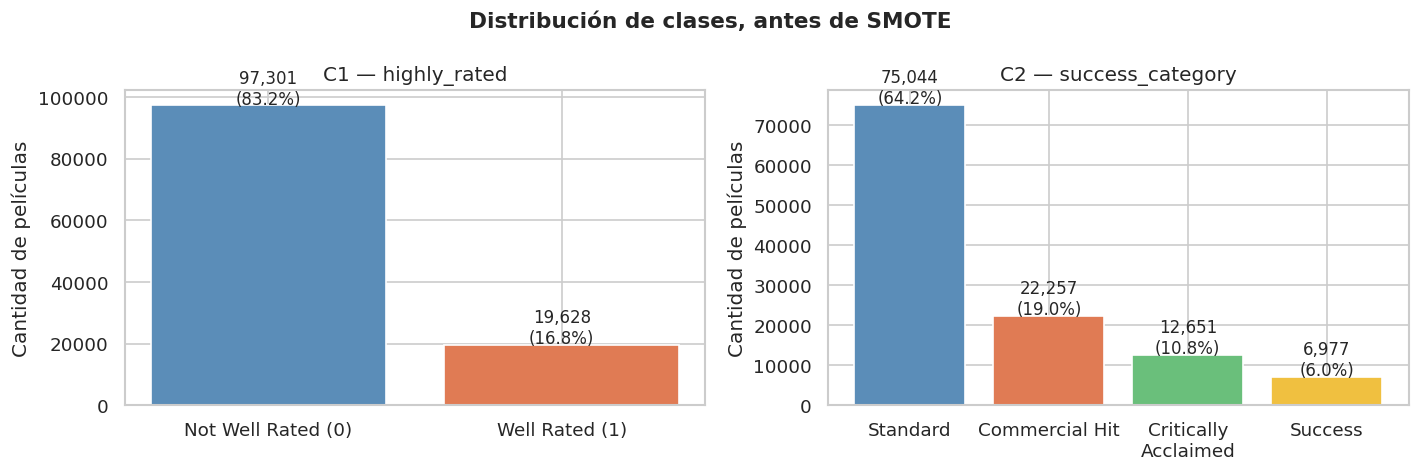

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_c1 = ['Not Well Rated (0)', 'Well Rated (1)']
counts_c1 = y_c1.value_counts().sort_index()
axes[0].bar(labels_c1, counts_c1, color=['#5b8db8', '#e07b54'])
axes[0].set_title('C1 — highly_rated')
axes[0].set_ylabel('Cantidad de películas')
for i, v in enumerate(counts_c1):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(y_c1)*100:.1f}%)',
                 ha='center', fontsize=10)


labels_c2 = ['Standard', 'Commercial Hit', 'Critically\nAcclaimed', 'Success']
counts_c2 = y_c2.value_counts().sort_index()
axes[1].bar(labels_c2, counts_c2, color=['#5b8db8', '#e07b54', '#6abf7b', '#f0c040'])
axes[1].set_title('C2 — success_category')
axes[1].set_ylabel('Cantidad de películas')
for i, v in enumerate(counts_c2):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(y_c2)*100:.1f}%)',
                 ha='center', fontsize=10)

plt.suptitle('Distribución de clases, antes de SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- `C1`: `97,301` vs `19,628`.  
  Por cada película bien valorada hay casi 5 mal valoradas.

- `C2`: `Standard` tiene `75,044` y `Success` solo `6,977`.  
  La clase más pequeña es 10 veces menor que la más grande.

## 4. Validación Cruzada 5-Fold con SMOTE

Se usa `StratifiedKFold` con 5 particiones para garantizar que cada fold tenga la misma proporción de clases que el dataset original. En cada iteración: se divide el dataset, se aplica SMOTE solo al entrenamiento, se entrena un `GaussianNB` y se evalúa sobre el conjunto de prueba sin modificar.

**¿Por qué GaussianNB?** Asume que cada feature sigue una distribución normal dentro de cada clase. Es una simplificación, pero funciona razonablemente con features continuas como `runtime` y `release_year`. Para las features binarias de géneros la aproximación es menos precisa, pero permite comparar directamente con los demás modelos del proyecto usando el mismo conjunto de features.

## ¿Por qué esto es un problema?

Imagina que entrenas un modelo con estos datos sin hacer nada. El modelo descubre rápidamente que si siempre predice `"Standard"` o `"Not Well Rated"`, se equivoca poco, porque esas clases dominan.

Entonces aprende a ignorar las clases minoritarias y aun así obtiene un `accuracy` alto.

Por ejemplo, en `C1`, predecir siempre `0` da aproximadamente un `83%` de `accuracy` sin aprender nada útil.

## Implementación de naive bayes

El modelo se llama "ingenuo" porque asume que todas las features son independientes entre sí. Es decir, asume que saber que una película es de acción no te dice nada sobre si también es de aventura.

## ¿Cómo decide la clase?

Usa el teorema de Bayes. En palabras simples:

```text
P(bien valorada | es Drama, dura 90min, año 2010)
    = P(es Drama | bien valorada) × P(dura 90min | bien valorada) × ...
        dividido entre algo que normaliza
```

Para cada clase calcula esa probabilidad y elige la más alta.

## ¿Qué variante usamos?

Aquí está el problema: nuestras 24 features son de tipos distintos:

| Feature                         | Tipo |
|---------------------------------|------|
| `runtime`, `release_year`       | Números continuos |
| `adult_int`, géneros            | Binarias (`0` o `1`) |
| `lang_encoded`                  | Categórica ordinal |
| `duration_encoded`              | Ordinal |


##  Como codificaremos


Vamos a implementar la validación cruzada `5-fold` con `SMOTE`.  
Te explico la estructura antes de escribirla:

Para cada fold (`5` veces):

1. Dividir `X` en entrenamiento y prueba
2. Aplicar `SMOTE` solo al entrenamiento
3. Entrenar `GaussianNB`
4. Evaluar en el conjunto de prueba (sin `SMOTE`)
5. Guardar métricas

Al final: promediar las `5` métricas.

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
smote = SMOTE(random_state=RANDOM_STATE)


results_c1 = []


print(f'{"Fold":<6} {"Accuracy":<10} {"Precision":<11} {"Recall":<8} {"F1":<8} {"AUC":<8}')
print('─' * 55)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_c1), 1):
    # split
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_c1.iloc[train_idx], y_c1.iloc[test_idx]

    # SMOTE solo en entrenamiento
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # entrenar
    model_c1 = GaussianNB()
    model_c1.fit(X_train_sm, y_train_sm)

    # predecir
    y_pred  = model_c1.predict(X_test)
    y_proba = model_c1.predict_proba(X_test)[:, 1]

    # métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    results_c1.append([acc, prec, rec, f1, auc])
    print(f'{fold:<6} {acc:<10.3f} {prec:<11.3f} {rec:<8.3f} {f1:<8.3f} {auc:<8.3f}')

# promedios
means_c1 = np.mean(results_c1, axis=0)
print('─' * 55)
print(f'{"Media":<6} {means_c1[0]:<10.3f} {means_c1[1]:<11.3f} {means_c1[2]:<8.3f} {means_c1[3]:<8.3f} {means_c1[4]:<8.3f}')

Fold   Accuracy   Precision   Recall   F1       AUC     
───────────────────────────────────────────────────────
1      0.517      0.199       0.622    0.302    0.606   
2      0.523      0.197       0.599    0.296    0.601   
3      0.514      0.198       0.620    0.300    0.603   
4      0.518      0.197       0.611    0.298    0.603   
5      0.517      0.195       0.602    0.295    0.604   
───────────────────────────────────────────────────────
Media  0.518      0.197       0.611    0.298    0.603   


In [17]:
results_c2 = []


print(f'{"Fold":<6} {"Accuracy":<10} {"Precision":<11} {"Recall":<8} {"F1":<8} {"AUC":<8}')
print('─' * 55)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_c2), 1):
    # split
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_c2.iloc[train_idx], y_c2.iloc[test_idx]

    # SMOTE solo en entrenamiento
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # entrenar
    model_c2 = GaussianNB()
    model_c2.fit(X_train_sm, y_train_sm)

    # predecir
    y_pred  = model_c2.predict(X_test)
    y_proba = model_c2.predict_proba(X_test)

    # metricas
    # weighted promedia por tamaño de clase, macro da igual peso a cada clase
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    results_c2.append([acc, prec, rec, f1, auc])
    print(f'{fold:<6} {acc:<10.3f} {prec:<11.3f} {rec:<8.3f} {f1:<8.3f} {auc:<8.3f}')

means_c2 = np.mean(results_c2, axis=0)
print(f'Media C2:')
print(f'  Accuracy  : {means_c2[0]:.3f}')
print(f'  Precision : {means_c2[1]:.3f}')
print(f'  Recall    : {means_c2[2]:.3f}')
print(f'  F1        : {means_c2[3]:.3f}')
print(f'  AUC       : {means_c2[4]:.3f}')


Fold   Accuracy   Precision   Recall   F1       AUC     
───────────────────────────────────────────────────────
1      0.279      0.508       0.279    0.273    0.561   
2      0.281      0.498       0.281    0.274    0.556   
3      0.278      0.514       0.278    0.275    0.560   
4      0.274      0.498       0.274    0.267    0.552   
5      0.276      0.502       0.276    0.268    0.554   
Media C2:
  Accuracy  : 0.278
  Precision : 0.504
  Recall    : 0.278
  F1        : 0.271
  AUC       : 0.557


## 5. Visualizaciones: Matriz de Confusión y Curva ROC

Se reentrena el modelo sobre el último fold para obtener las predicciones individuales necesarias para las visualizaciones. La **matriz de confusión** muestra exactamente dónde se equivoca el modelo clase por clase. La **curva ROC** muestra la capacidad discriminativa global: una curva pegada al eje superior izquierdo indica un modelo casi perfecto; una curva sobre la diagonal punteada indica desempeño equivalente al azar.

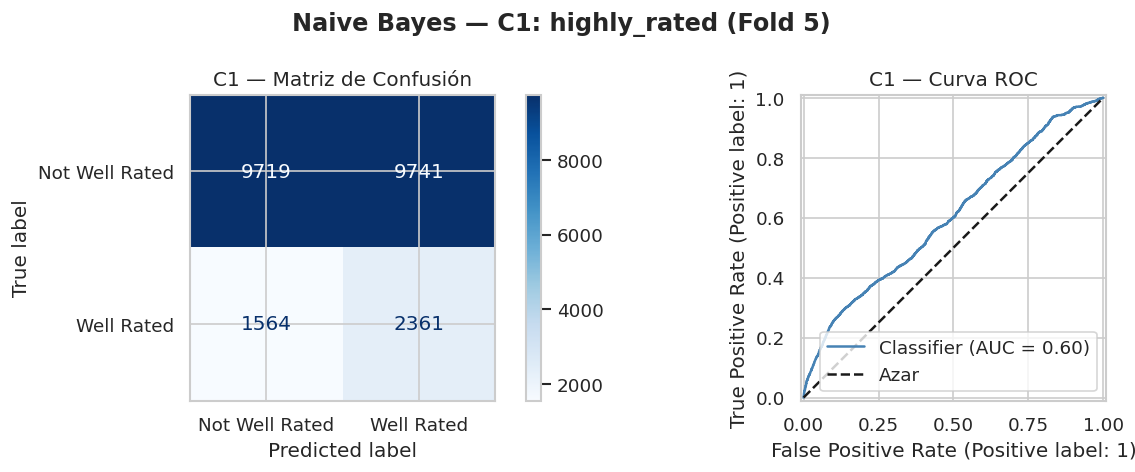

In [18]:
train_idx, test_idx = list(skf.split(X, y_c1))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_c1.iloc[train_idx], y_c1.iloc[test_idx]

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
model_c1 = GaussianNB()
model_c1.fit(X_train_sm, y_train_sm)
y_pred_c1  = model_c1.predict(X_test)
y_proba_c1 = model_c1.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('C1 — Matriz de Confusión')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_proba_c1, ax=axes[1], color='steelblue'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_title('C1 — Curva ROC')
axes[1].legend()

plt.suptitle('Naive Bayes — C1: highly_rated (Fold 5)', fontweight='bold')
plt.tight_layout()
plt.show()

- `9741` falsos positivos: películas que **NO** son bien valoradas pero el modelo dijo que sí.  
  Esto explica la `Precision` baja (`0.197`): el modelo es demasiado optimista.

- `1564` falsos negativos: películas que **SÍ** son bien valoradas pero el modelo las perdió.  
  Son relativamente pocos gracias al `SMOTE`, por eso el `Recall` es decente (`0.611`).

Ahora hagamos C2:

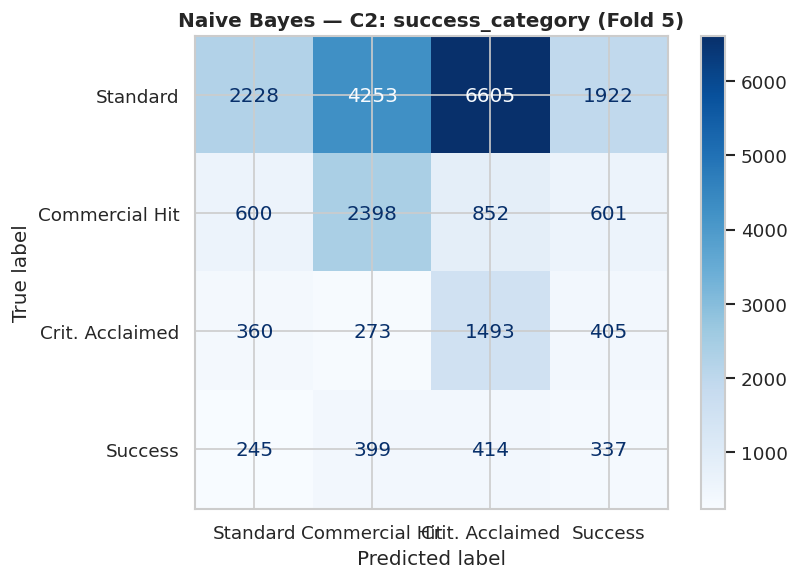

In [19]:
train_idx, test_idx = list(skf.split(X, y_c2))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_c2.iloc[train_idx], y_c2.iloc[test_idx]

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
model_c2 = GaussianNB()
model_c2.fit(X_train_sm, y_train_sm)
y_pred_c2  = model_c2.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c2,
    display_labels=['Standard', 'Commercial Hit', 'Crit. Acclaimed', 'Success'],
    cmap='Blues', ax=ax
)
ax.set_title('Naive Bayes — C2: success_category (Fold 5)', fontweight='bold')
plt.tight_layout()
plt.show()

- **Standard** (fila 1): de `15,008` películas reales, solo `2,228` las predijo bien.  
  El modelo confunde muchísimas como `"Critically Acclaimed"` (`6,605`). Está sobreprediciendo esa clase.

- **Commercial Hit** (fila 2): de `4,451` reales, acierta `2,398`.  
  Es la clase que mejor predice proporcionalmente.

- **Critically Acclaimed** (fila 3): de `2,531` reales, acierta `1,493`.  
  Razonable, pero confunde bastante con `Commercial Hit` y `Success`.

- **Success** (fila 4): de `1,395` reales, solo acierta `337`.  
  La clase más difícil: el modelo la confunde con todo. Apenas encuentra `1` de cada `4`.

## 6. Función de Inferencia

Los modelos finales se reentrenan sobre el **dataset completo** con SMOTE para aprovechar toda la información disponible. La función `predecir_pelicula()` aplica exactamente el mismo pipeline de preprocesamiento del entrenamiento y permite predecir sobre películas nuevas a partir de sus características básicas de contenido,sin necesidad de conocer su rating o popularidad.

In [20]:
X_full_sm_c1, y_full_sm_c1 = smote.fit_resample(X, y_c1)
final_model_c1 = GaussianNB()
final_model_c1.fit(X_full_sm_c1, y_full_sm_c1)

X_full_sm_c2, y_full_sm_c2 = smote.fit_resample(X, y_c2)
final_model_c2 = GaussianNB()
final_model_c2.fit(X_full_sm_c2, y_full_sm_c2)

print('Modelos finales entrenados sobre el dataset completo.')

Modelos finales entrenados sobre el dataset completo.


In [21]:
cat_map_inv = {0: 'Standard', 1: 'Commercial Hit', 2: 'Critically Acclaimed', 3: 'Success'}

def predecir_pelicula(titulo, generos, duracion_min, anio, idioma='en', es_adulto=False):
    """
    titulo       : str   → solo para mostrar, no entra al modelo
    generos      : list  → ej. ['Action', 'Adventure']
    duracion_min : int   → duración en minutos
    anio         : int   → año de lanzamiento
    idioma       : str   → código de idioma, ej. 'en', 'es', 'fr'
    es_adulto    : bool  → contenido adulto
    """

    idioma_enc = idioma if idioma in top_langs else 'other'
    idioma_num = le.transform([idioma_enc])[0]

    # 2. Codificar duración
    if duracion_min <= 82:
        dur_enc = 0       # Short
    elif duracion_min <= 92:
        dur_enc = 1       # Standard
    elif duracion_min <= 104:
        dur_enc = 2       # Long
    else:
        dur_enc = 3       # Very long

    generos_enc = mlb.transform([generos])
    df_gen = pd.DataFrame(generos_enc, columns=GENRE_COLS)

    fila = pd.DataFrame([{
        'runtime'          : duracion_min,
        'release_year'     : anio,
        'adult_int'        : int(es_adulto),
        'lang_encoded'     : idioma_num,
        'duration_encoded' : dur_enc
    }])
    fila = pd.concat([fila.reset_index(drop=True),
                      df_gen.reset_index(drop=True)], axis=1)
    fila = fila[FEATURES]

    pred_c1    = final_model_c1.predict(fila)[0]
    proba_c1   = final_model_c1.predict_proba(fila)[0][1]
    pred_c2    = final_model_c2.predict(fila)[0]
    proba_c2   = final_model_c2.predict_proba(fila)[0]

    print(f' Predicción: {titulo}')
    print(f'  Géneros      : {", ".join(generos)}')
    print(f'  Duración     : {duracion_min} min | Año: {anio} | Idioma: {idioma}')
    print(f'')
    print(f'  C1 — Bien valorada : {"✓ Sí" if pred_c1 == 1 else "✗ No"} (probabilidad: {proba_c1:.1%})')
    print(f'  C2 — Categoría     : {cat_map_inv[pred_c2]}')
    print(f'')
    print(f'  Probabilidades C2:')
    for i, cat in cat_map_inv.items():
        bar = '█' * int(proba_c2[i] * 30)
        print(f'    {cat:<22} {proba_c2[i]:.1%}  {bar}')

In [22]:
predecir_pelicula('Inception',
    generos=['Action', 'Science Fiction', 'Adventure'],
    duracion_min=148, anio=2010, idioma='en')

 Predicción: Inception
  Géneros      : Action, Science Fiction, Adventure
  Duración     : 148 min | Año: 2010 | Idioma: en

  C1 — Bien valorada : ✗ No (probabilidad: 0.0%)
  C2 — Categoría     : Commercial Hit

  Probabilidades C2:
    Standard               0.0%  
    Commercial Hit         100.0%  █████████████████████████████
    Critically Acclaimed   0.0%  
    Success                0.0%  


In [23]:
predecir_pelicula('Amélie',
    generos=['Romance', 'Comedy'],
    duracion_min=122, anio=2001, idioma='fr')

 Predicción: Amélie
  Géneros      : Romance, Comedy
  Duración     : 122 min | Año: 2001 | Idioma: fr

  C1 — Bien valorada : ✓ Sí (probabilidad: 92.5%)
  C2 — Categoría     : Success

  Probabilidades C2:
    Standard               0.3%  
    Commercial Hit         39.6%  ███████████
    Critically Acclaimed   0.9%  
    Success                59.2%  █████████████████


In [24]:
predecir_pelicula('Paranormal Activity',
    generos=['Horror', 'Thriller'],
    duracion_min=86, anio=2007, idioma='en')

 Predicción: Paranormal Activity
  Géneros      : Horror, Thriller
  Duración     : 86 min | Año: 2007 | Idioma: en

  C1 — Bien valorada : ✗ No (probabilidad: 0.0%)
  C2 — Categoría     : Commercial Hit

  Probabilidades C2:
    Standard               0.2%  
    Commercial Hit         99.8%  █████████████████████████████
    Critically Acclaimed   0.0%  
    Success                0.0%  


## 7. Conclusiones

### Resultados obtenidos

| | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| **C1 — Naive Bayes** | 0.518 | 0.197 | 0.611 | 0.298 | 0.603 |
| **C1 — Redes Neuronales** | 0.762 | 0.357 | 0.522 | 0.424 | 0.757 |
| **C2 — Naive Bayes** | 0.278 | 0.504 | 0.278 | 0.271 | 0.557 |
| **C2 — Redes Neuronales** | 0.455 | 0.634 | 0.455 | 0.459 | 0.732 |

### Análisis

**Naive Bayes es el modelo más simple del proyecto y sus resultados lo reflejan.** En C1 obtiene un AUC de 0.603, lo que confirma que existe capacidad discriminativa real — el modelo aprende algo genuino a partir de géneros, duración e idioma — pero limitada por la naturaleza del problema: `vote_average` tiene correlaciones débiles con todas las variables estructurales, como ya mostraba el EDA.

El resultado más interesante es el **Recall de C1 (0.611 vs 0.522 de Redes Neuronales)**. Naive Bayes encuentra más películas bien valoradas, aunque a costa de muchos falsos positivos (Precision 0.197). Esto se debe a que SMOTE empuja al modelo hacia la clase minoritaria de forma más agresiva, y Naive Bayes, al ser un modelo más simple, responde de manera más extrema a ese rebalanceo.

En C2 el desempeño cae considerablemente (AUC 0.557). Las cuatro categorías no son linealmente separables con estas features, y la matriz de confusión revela que el modelo tiene un sesgo claro hacia "Critically Acclaimed", confundiendo con esa clase gran parte de las películas de otras categorías. La clase `Success` es prácticamente imposible de identificar — solo recupera 1 de cada 4 casos.

### Limitaciones de Naive Bayes en este problema

**1. Independencia entre features:** Naive Bayes asume que saber que una película es de Action no dice nada sobre si también es de Adventure. Las reglas de asociación del proyecto demostraron exactamente lo contrario. Action y Adventure tienen lift 3.3. Esta suposición viola la estructura real de los datos.

**2. Probabilidades extremas:** Los resultados de la función de inferencia muestran probabilidades de 0% o 100% con frecuencia. Esto es un comportamiento conocido de GaussianNB cuando las features están correlacionadas,las probabilidades se vuelven demasiado extremas y poco calibradas.

**3. Features binarias con distribución gaussiana:** Los 19 géneros son variables binarias (0/1), pero GaussianNB asume distribución normal. BernoulliNB sería teóricamente más correcto para esas features, aunque en la práctica la diferencia en AUC suele ser marginal.

### Conclusión general

Naive Bayes establece un **baseline sólido y rápido** para el problema. Sus resultados honestos — AUC 0.603 en C1 y 0.557 en C2 , son coherentes con lo que el EDA anticipaba: predecir calidad y éxito comercial desde características estructurales de contenido es una tarea genuinamente difícil con un techo natural bajo. Las Redes Neuronales superan a Naive Bayes en todas las métricas principales gracias a su capacidad de capturar interacciones no lineales entre features, algo que Naive Bayes no puede hacer por construcción.